# ClarityNet: Train/Validation/Test Split and Dataset Creation

This notebook:
1. Implements proper train/val/test splits for seen and unseen noise types
2. Uses improved noise categorization based on acoustic properties
3. Creates separate datasets with fixed validation/test pairs for consistent metrics
4. Demonstrates the complete data pipeline ready for model training

**Key Design:**
- **Training:** Random SNR/noise pairing each epoch (infinite augmentation)
- **Validation/Test:** Fixed pairs for deterministic, comparable metrics
- **Seen/Unseen split:** Tests generalization across acoustic characteristics

In [1]:
# Imports
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from collections import defaultdict
import json

# Set random seeds
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print("Imports successful!")

Imports successful!


## Configuration

In [2]:
# Audio parameters
SAMPLE_RATE = 16000
SEGMENT_DURATION = 4.0
SEGMENT_SAMPLES = int(SAMPLE_RATE * SEGMENT_DURATION)

# STFT parameters
N_FFT = 512
HOP_LENGTH = 128

# SNR range
SNR_MIN_DB = 0
SNR_MAX_DB = 20

# Data paths
DATA_DIR = Path("../data/raw")
CLEAN_DIR = DATA_DIR / "clean_speech"
NOISE_DIR = DATA_DIR / "noise"

# Split ratios
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

print("Configuration loaded")

Configuration loaded


## Noise Categorization by Acoustic Properties

ESC-50 categories grouped by acoustic characteristics rather than semantic labels.
This enables testing generalization across different types of noise patterns.

In [3]:
# ESC-50 category numbers mapped to acoustic groups
NOISE_GROUPS = {
    # SEEN (Training) - Continuous, stationary patterns
    "natural_continuous": [10, 11, 12, 15, 16, 17, 19],  # rain, sea waves, fire, water drops, wind, pouring water, thunderstorm
    "domestic_mechanical": [35, 36],                     # washing machine, vacuum cleaner, clock tick
    
    # UNSEEN (Testing) - Different acoustic characteristics
    "transport_urban": [40, 42, 43, 44, 45, 47],         # helicopter, siren, car horn, engine, train, airplane
    "impulsive_events": [30, 34, 39, 46, 48, 49],        # door knock, can opening, glass breaking, church bells, fireworks, hand saw
}

# Define which groups are seen vs unseen
SEEN_GROUPS = ["natural_continuous", "domestic_mechanical"]
UNSEEN_GROUPS = ["transport_urban", "impulsive_events"]

# Flatten to category numbers
SEEN_CATEGORIES = [cat for group in SEEN_GROUPS for cat in NOISE_GROUPS[group]]
UNSEEN_CATEGORIES = [cat for group in UNSEEN_GROUPS for cat in NOISE_GROUPS[group]]

print("Noise categorization:")
print(f"\nSEEN (Training):")
for group in SEEN_GROUPS:
    print(f"  {group}: {NOISE_GROUPS[group]}")
print(f"\nUNSEEN (Testing):")
for group in UNSEEN_GROUPS:
    print(f"  {group}: {NOISE_GROUPS[group]}")
print(f"\nTotal seen categories: {len(SEEN_CATEGORIES)}")
print(f"Total unseen categories: {len(UNSEEN_CATEGORIES)}")

Noise categorization:

SEEN (Training):
  natural_continuous: [10, 11, 12, 15, 16, 17, 19]
  domestic_mechanical: [35, 36]

UNSEEN (Testing):
  transport_urban: [40, 42, 43, 44, 45, 47]
  impulsive_events: [30, 34, 39, 46, 48, 49]

Total seen categories: 9
Total unseen categories: 12


## Helper Functions

In [4]:
def load_audio(filepath: str, sr: int = SAMPLE_RATE) -> np.ndarray:
    """Load audio file and resample to target sample rate."""
    audio, _ = librosa.load(filepath, sr=sr, mono=True)
    return audio


def slice_audio(audio: np.ndarray, segment_length: int = SEGMENT_SAMPLES) -> list:
    """Slice audio into fixed-length segments with padding if necessary."""
    segments = []
    for start in range(0, len(audio), segment_length):
        segment = audio[start:start + segment_length]
        if len(segment) < segment_length:
            segment = np.pad(segment, (0, segment_length - len(segment)))
        segments.append(segment)
    return segments


def mix_at_snr(clean: np.ndarray, noise: np.ndarray, target_snr_db: float) -> np.ndarray:
    """Mix clean speech with noise at target SNR."""
    clean_power = np.mean(clean ** 2)
    noise_power = np.mean(noise ** 2)
    
    if clean_power == 0 or noise_power == 0:
        return clean.copy()
    
    desired_noise_power = clean_power / (10 ** (target_snr_db / 10))
    noise_scaled = noise * np.sqrt(desired_noise_power / noise_power)
    noisy = np.clip(clean + noise_scaled, -1.0, 1.0)
    
    return noisy


def compute_stft(audio: np.ndarray) -> tuple:
    """Compute STFT magnitude and phase."""
    stft_complex = librosa.stft(audio, n_fft=N_FFT, hop_length=HOP_LENGTH)
    magnitude = np.abs(stft_complex)
    phase = np.angle(stft_complex)
    return magnitude, phase


def extract_category_from_filename(filename: str) -> int:
    """
    Extract ESC-50 category number from filename.
    Format: fold-clip_id-take-category.wav
    """
    try:
        parts = Path(filename).stem.split('-')
        if len(parts) >= 4:
            return int(parts[3])
    except (ValueError, IndexError):
        pass
    return None


print("✓ Helper functions defined")

✓ Helper functions defined


## Load and Organize Files

In [11]:
# Load clean speech files
clean_files = list(CLEAN_DIR.glob("*.flac")) + list(CLEAN_DIR.glob("*.wav"))
print(f"Found {len(clean_files)} clean speech files")

# Load noise files and categorize
all_noise_files = []
for noise_category in ["natural_continuous", "domestic_mechanical", "transport_urban", "impulsive_events"]:
    category_path = NOISE_DIR / noise_category
    if category_path.exists():
        files = list(category_path.glob("*.wav"))
        all_noise_files.extend(files)

print(f"Found {len(all_noise_files)} total noise files from organized directories")

# Categorize noise files by ESC-50 category number
seen_noise_files = []
unseen_noise_files = []

for noise_file in all_noise_files:
    category = extract_category_from_filename(noise_file.name)
    if category is not None:
        if category in SEEN_CATEGORIES:
            seen_noise_files.append(noise_file)
        elif category in UNSEEN_CATEGORIES:
            unseen_noise_files.append(noise_file)

print(f"\nCategorized by seen/unseen:")
print(f"  Seen noise files: {len(seen_noise_files)}")
print(f"  Unseen noise files: {len(unseen_noise_files)}")

# If you have manually added music files, add them here
music_dir_seen = NOISE_DIR / "background_music"
music_dir_unseen = NOISE_DIR / "music_interference"

if music_dir_seen.exists():
    music_seen = list(music_dir_seen.glob("*.wav")) + list(music_dir_seen.glob("*.mp3"))
    seen_noise_files.extend(music_seen)
    print(f"  Added {len(music_seen)} background music files to SEEN")

if music_dir_unseen.exists():
    music_unseen = list(music_dir_unseen.glob("*.wav")) + list(music_dir_unseen.glob("*.mp3"))
    unseen_noise_files.extend(music_unseen)
    print(f"  Added {len(music_unseen)} music interference files to UNSEEN")

print(f"\nFinal totals:")
print(f"  Clean speech: {len(clean_files)}")
print(f"  Seen noise: {len(seen_noise_files)}")
print(f"  Unseen noise: {len(unseen_noise_files)}")

Found 200 clean speech files
Found 60 total noise files from organized directories

Categorized by seen/unseen:
  Seen noise files: 23
  Unseen noise files: 30
  Added 0 background music files to SEEN
  Added 0 music interference files to UNSEEN

Final totals:
  Clean speech: 200
  Seen noise: 23
  Unseen noise: 30


## Split Clean Speech into Train/Val/Test

In [ ]:
# Set seed for reproducibility
random.seed(42)

# Shuffle clean files
random.shuffle(clean_files)

# Calculate split indices
n_total = len(clean_files)
n_train = int(n_total * TRAIN_RATIO)
n_val = int(n_total * VAL_RATIO)

# Split
clean_train = clean_files[:n_train]
clean_val = clean_files[n_train:n_train + n_val]
clean_test = clean_files[n_train + n_val:]

print(f"Clean speech split:")
print(f"  Train: {len(clean_train)} files ({len(clean_train)/n_total*100:.1f}%)")
print(f"  Val:   {len(clean_val)} files ({len(clean_val)/n_total*100:.1f}%)")
print(f"  Test:  {len(clean_test)} files ({len(clean_test)/n_total*100:.1f}%)")

# Save split for reproducibility
split_info = {
    "train": [str(f) for f in clean_train],
    "val": [str(f) for f in clean_val],
    "test": [str(f) for f in clean_test]
}

# Create output directory if needed
split_dir = Path("data/splits")
split_dir.mkdir(parents=True, exist_ok=True)

with open(split_dir / "clean_speech_split.json", "w") as f:
    json.dump(split_info, f, indent=2)

print("\n✓ Split saved to data/splits/clean_speech_split.json")

Clean speech split:
  Train: 140 files (70.0%)
  Val:   30 files (15.0%)
  Test:  30 files (15.0%)

✓ Split saved to data/splits/clean_speech_split.json


## PyTorch Dataset with Fixed Val/Test Pairs

In [7]:
class SpeechEnhancementDataset(Dataset):
    """
    Speech Enhancement Dataset with mode-dependent behavior:
    - train: Random SNR and noise pairing each epoch (infinite augmentation)
    - val/test: Fixed pairs for deterministic metrics
    """
    
    def __init__(self,
                 clean_files: list,
                 noise_files: list,
                 mode: str = 'train',
                 snr_range: tuple = (SNR_MIN_DB, SNR_MAX_DB),
                 segment_length: int = SEGMENT_SAMPLES,
                 sample_rate: int = SAMPLE_RATE):
        """
        Args:
            clean_files: List of clean speech file paths
            noise_files: List of noise file paths
            mode: 'train', 'val', or 'test'
            snr_range: (min_snr, max_snr) in dB
            segment_length: Audio segment length in samples
            sample_rate: Audio sample rate
        """
        assert mode in ['train', 'val', 'test'], "Mode must be 'train', 'val', or 'test'"
        
        self.mode = mode
        self.snr_range = snr_range
        self.segment_length = segment_length
        self.sample_rate = sample_rate
        
        # Load and slice clean speech
        print(f"[{mode.upper()}] Loading {len(clean_files)} clean speech files...")
        self.clean_segments = []
        for clean_file in clean_files:
            audio = load_audio(str(clean_file), sr=sample_rate)
            segments = slice_audio(audio, segment_length)
            self.clean_segments.extend(segments)
        
        # Load and slice noise
        print(f"[{mode.upper()}] Loading {len(noise_files)} noise files...")
        self.noise_segments = []
        for noise_file in noise_files:
            audio = load_audio(str(noise_file), sr=sample_rate)
            segments = slice_audio(audio, segment_length)
            self.noise_segments.extend(segments)
        
        print(f"[{mode.upper()}] Prepared {len(self.clean_segments)} clean segments, {len(self.noise_segments)} noise segments")
        
        # For val/test: pre-generate fixed pairs
        if mode in ['val', 'test']:
            print(f"[{mode.upper()}] Generating fixed pairs for deterministic evaluation...")
            self.fixed_pairs = self._generate_fixed_pairs()
            print(f"[{mode.upper()}] ✓ Generated {len(self.fixed_pairs)} fixed pairs")
    
    def _generate_fixed_pairs(self):
        """
        Pre-generate fixed (clean, noisy) pairs for val/test.
        Each clean segment gets paired with a random noise at random SNR,
        but these pairings stay fixed across epochs.
        """
        pairs = []
        for clean_seg in self.clean_segments:
            # Fix noise and SNR for this clean segment
            noise_seg = random.choice(self.noise_segments)
            snr = random.uniform(*self.snr_range)
            noisy_seg = mix_at_snr(clean_seg, noise_seg, snr)
            pairs.append((clean_seg, noisy_seg, snr))
        return pairs
    
    def __len__(self):
        return len(self.clean_segments)
    
    def __getitem__(self, idx):
        if self.mode == 'train':
            # Training: random augmentation every epoch
            clean = self.clean_segments[idx]
            noise = random.choice(self.noise_segments)
            snr = random.uniform(*self.snr_range)
            noisy = mix_at_snr(clean, noise, snr)
        else:
            # Val/test: use fixed pairs
            clean, noisy, snr = self.fixed_pairs[idx]
        
        # Compute spectrograms
        clean_mag, _ = compute_stft(clean)
        noisy_mag, noisy_phase = compute_stft(noisy)
        
        # Convert to tensors with channel dimension
        noisy_tensor = torch.tensor(noisy_mag, dtype=torch.float32).unsqueeze(0)
        clean_tensor = torch.tensor(clean_mag, dtype=torch.float32).unsqueeze(0)
        
        # Also return phase for waveform reconstruction during inference
        phase_tensor = torch.tensor(noisy_phase, dtype=torch.float32)
        
        return {
            'noisy': noisy_tensor,
            'clean': clean_tensor,
            'phase': phase_tensor,
            'snr': snr
        }


print("✓ SpeechEnhancementDataset class defined")

✓ SpeechEnhancementDataset class defined


## Create All Datasets

In [12]:
print("="*60)
print("Creating datasets...")
print("="*60)

# Training set (seen noise only)
train_dataset = SpeechEnhancementDataset(
    clean_files=clean_train,
    noise_files=seen_noise_files,
    mode='train'
)

print()

# Validation set - SEEN noise
val_seen_dataset = SpeechEnhancementDataset(
    clean_files=clean_val,
    noise_files=seen_noise_files,
    mode='val'
)

print()

# Validation set - UNSEEN noise
val_unseen_dataset = SpeechEnhancementDataset(
    clean_files=clean_val,
    noise_files=unseen_noise_files,
    mode='val'
)

print()

# Test set - SEEN noise
test_seen_dataset = SpeechEnhancementDataset(
    clean_files=clean_test,
    noise_files=seen_noise_files,
    mode='test'
)

print()

# Test set - UNSEEN noise
test_unseen_dataset = SpeechEnhancementDataset(
    clean_files=clean_test,
    noise_files=unseen_noise_files,
    mode='test'
)

print()
print("="*60)
print("Dataset Summary")
print("="*60)
print(f"Training:          {len(train_dataset):4d} pairs (SEEN noise, random augmentation)")
print(f"Validation (seen): {len(val_seen_dataset):4d} pairs (SEEN noise, fixed pairs)")
print(f"Validation (unseen): {len(val_unseen_dataset):4d} pairs (UNSEEN noise, fixed pairs)")
print(f"Test (seen):       {len(test_seen_dataset):4d} pairs (SEEN noise, fixed pairs)")
print(f"Test (unseen):     {len(test_unseen_dataset):4d} pairs (UNSEEN noise, fixed pairs)")
print("="*60)

Creating datasets...
[TRAIN] Loading 140 clean speech files...
[TRAIN] Loading 23 noise files...
[TRAIN] Prepared 247 clean segments, 46 noise segments

[VAL] Loading 30 clean speech files...
[VAL] Loading 23 noise files...
[VAL] Prepared 54 clean segments, 46 noise segments
[VAL] Generating fixed pairs for deterministic evaluation...
[VAL] ✓ Generated 54 fixed pairs

[VAL] Loading 30 clean speech files...
[VAL] Loading 30 noise files...
[VAL] Prepared 54 clean segments, 60 noise segments
[VAL] Generating fixed pairs for deterministic evaluation...
[VAL] ✓ Generated 54 fixed pairs

[TEST] Loading 30 clean speech files...
[TEST] Loading 23 noise files...
[TEST] Prepared 53 clean segments, 46 noise segments
[TEST] Generating fixed pairs for deterministic evaluation...
[TEST] ✓ Generated 53 fixed pairs

[TEST] Loading 30 clean speech files...
[TEST] Loading 30 noise files...
[TEST] Prepared 53 clean segments, 60 noise segments
[TEST] Generating fixed pairs for deterministic evaluation...


## Create DataLoaders

In [13]:
BATCH_SIZE = 8
NUM_WORKERS = 0  # Increase to 2-4 for faster loading in actual training

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_seen_loader = DataLoader(
    val_seen_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,  # No shuffle for validation
    num_workers=NUM_WORKERS
)

val_unseen_loader = DataLoader(
    val_unseen_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_seen_loader = DataLoader(
    test_seen_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_unseen_loader = DataLoader(
    test_unseen_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print(f"DataLoaders created with batch size {BATCH_SIZE}")
print(f"\nBatches per loader:")
print(f"  Train:          {len(train_loader)}")
print(f"  Val (seen):     {len(val_seen_loader)}")
print(f"  Val (unseen):   {len(val_unseen_loader)}")
print(f"  Test (seen):    {len(test_seen_loader)}")
print(f"  Test (unseen):  {len(test_unseen_loader)}")

DataLoaders created with batch size 8

Batches per loader:
  Train:          31
  Val (seen):     7
  Val (unseen):   7
  Test (seen):    7
  Test (unseen):  7


## Verify DataLoader Output

In [14]:
# Fetch one batch from training
train_batch = next(iter(train_loader))

print("Training batch structure:")
print(f"  Keys: {train_batch.keys()}")
print(f"\nShapes:")
print(f"  Noisy: {train_batch['noisy'].shape}  (batch, channels, freq_bins, time_frames)")
print(f"  Clean: {train_batch['clean'].shape}")
print(f"  Phase: {train_batch['phase'].shape}  (batch, freq_bins, time_frames)")
print(f"  SNR:   {train_batch['snr'].shape}    (batch,)")
print(f"\nData types:")
print(f"  Noisy: {train_batch['noisy'].dtype}")
print(f"  Clean: {train_batch['clean'].dtype}")
print(f"\nSNR values in this batch (dB):")
print(f"  {train_batch['snr'].numpy()}")

Training batch structure:
  Keys: dict_keys(['noisy', 'clean', 'phase', 'snr'])

Shapes:
  Noisy: torch.Size([8, 1, 257, 501])  (batch, channels, freq_bins, time_frames)
  Clean: torch.Size([8, 1, 257, 501])
  Phase: torch.Size([8, 257, 501])  (batch, freq_bins, time_frames)
  SNR:   torch.Size([8])    (batch,)

Data types:
  Noisy: torch.float32
  Clean: torch.float32

SNR values in this batch (dB):
  [10.68270179  0.91031402 11.06717934 18.8817923  17.36922395  2.05175294
 11.48128439  9.57428417]


## Test Fixed Pairs in Validation Set

In [15]:
# Fetch the same batch twice from validation to verify it's fixed
val_batch_1 = next(iter(val_seen_loader))
val_batch_2 = next(iter(val_seen_loader))

# Check if noisy spectrograms are identical
noisy_diff = torch.abs(val_batch_1['noisy'] - val_batch_2['noisy']).sum().item()
snr_diff = torch.abs(val_batch_1['snr'] - val_batch_2['snr']).sum().item()

print("Validation set consistency check:")
print(f"  Difference in noisy spectrograms: {noisy_diff:.6f}")
print(f"  Difference in SNR values: {snr_diff:.6f}")

if noisy_diff == 0 and snr_diff == 0:
    print("\n✓ Validation pairs are FIXED (deterministic)")
else:
    print("\n✗ WARNING: Validation pairs are NOT fixed!")

Validation set consistency check:
  Difference in noisy spectrograms: 0.000000
  Difference in SNR values: 0.000000

✓ Validation pairs are FIXED (deterministic)


## Visualize Sample from Each Split

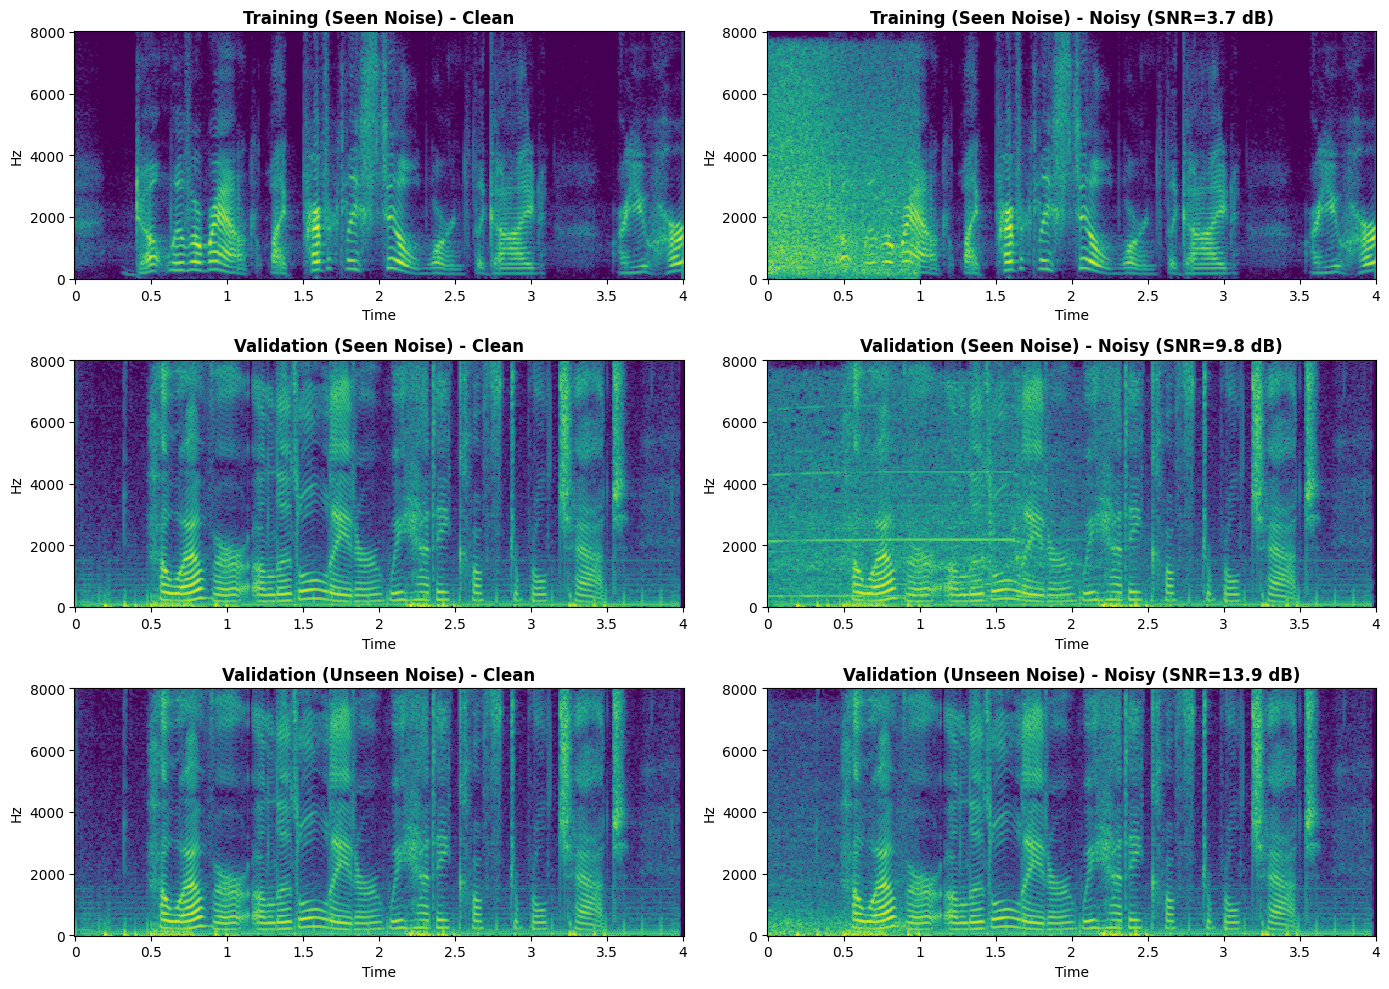

Visualization complete


In [16]:
# Get one sample from each dataset
train_sample = train_dataset[0]
val_seen_sample = val_seen_dataset[0]
val_unseen_sample = val_unseen_dataset[0]

# Create visualization
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

datasets_to_plot = [
    (train_sample, "Training (Seen Noise)"),
    (val_seen_sample, "Validation (Seen Noise)"),
    (val_unseen_sample, "Validation (Unseen Noise)")
]

for idx, (sample, title) in enumerate(datasets_to_plot):
    noisy_spec = sample['noisy'][0].numpy()  # Remove channel dim
    clean_spec = sample['clean'][0].numpy()
    snr = sample['snr']
    
    # Convert to dB
    noisy_db = librosa.amplitude_to_db(noisy_spec, ref=np.max)
    clean_db = librosa.amplitude_to_db(clean_spec, ref=np.max)
    
    # Plot clean
    img1 = librosa.display.specshow(
        clean_db,
        sr=SAMPLE_RATE,
        hop_length=HOP_LENGTH,
        x_axis='time',
        y_axis='hz',
        ax=axes[idx, 0],
        cmap='viridis'
    )
    axes[idx, 0].set_title(f'{title} - Clean', fontweight='bold')
    
    # Plot noisy
    img2 = librosa.display.specshow(
        noisy_db,
        sr=SAMPLE_RATE,
        hop_length=HOP_LENGTH,
        x_axis='time',
        y_axis='hz',
        ax=axes[idx, 1],
        cmap='viridis'
    )
    axes[idx, 1].set_title(f'{title} - Noisy (SNR={snr:.1f} dB)', fontweight='bold')

plt.tight_layout()
plt.show()

print("Visualization complete")

## Training Loop Template

Here's how you'd use these datasets in an actual training loop:

In [ ]:
def training_loop_example():
    """
    Template for training loop showing how to use the dataloaders.
    Not meant to be executed - just for reference.
    """
    
    # Pseudo-code for training
    for epoch in range(num_epochs):
        
        # ===== TRAINING PHASE =====
        # Random SNR/noise pairing each epoch
        model.train()
        train_loss = 0
        
        for batch in train_loader:
            noisy = batch['noisy']  # Input to model
            clean = batch['clean']  # Ground truth
            
            # Forward pass
            enhanced = model(noisy)
            loss = criterion(enhanced, clean)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # ===== VALIDATION PHASE =====
        # Fixed pairs for consistent metrics
        model.eval()
        
        with torch.no_grad():
            # Validation on SEEN noise
            val_seen_metrics = evaluate(model, val_seen_loader)
            
            # Validation on UNSEEN noise (generalization check)
            val_unseen_metrics = evaluate(model, val_unseen_loader)
        
        # Log metrics
        print(f"Epoch {epoch}:")
        print(f"  Train Loss: {train_loss / len(train_loader):.4f}")
        print(f"  Val (seen)   - PESQ: {val_seen_metrics['pesq']:.3f}")
        print(f"  Val (unseen) - PESQ: {val_unseen_metrics['pesq']:.3f}")
        print(f"  Generalization Gap: {val_seen_metrics['pesq'] - val_unseen_metrics['pesq']:.3f}")
        
        # Early stopping / checkpointing based on val_unseen performance
        # ...


print("Training loop template defined (not executed)")
print("\nKey points:")
print("  • Training: Random augmentation (different each epoch)")
print("  • Validation: Fixed pairs (same metrics each time)")
print("  • Monitor BOTH val_seen and val_unseen to track generalization")

## Summary

### What We've Built:

1. ✅ **Noise categorization by acoustic properties**
   - Seen: natural_continuous, domestic_mechanical
   - Unseen: transport_urban, impulsive_events

2. ✅ **Proper train/val/test splits**
   - 70% train / 15% val / 15% test for clean speech
   - Separate val/test sets for seen and unseen noise

3. ✅ **Mode-dependent datasets**
   - Training: Random SNR + noise pairing each epoch
   - Validation/Test: Fixed pairs for deterministic metrics

4. ✅ **Ready-to-use DataLoaders**
   - `train_loader`: For model training
   - `val_seen_loader`: Monitor overfitting
   - `val_unseen_loader`: Monitor generalization
   - `test_seen_loader`: Final seen performance
   - `test_unseen_loader`: **Core research metric**

### Next Steps:

1. Implement baseline CNN model (notebook 03)
2. Set up training loop with PESQ/STOI evaluation
3. Train and validate, tracking seen vs. unseen performance
4. Only touch test sets once for final evaluation

### Key Research Metrics:

- **Generalization Gap** = `PESQ(seen) - PESQ(unseen)`
- Lower gap = better generalization
- Your ablations should reduce this gap